# PnP-MSSN: Plug-and-Play MRI Reconstruction

This notebook demonstrates the **Plug-and-Play (PnP) Proximal Gradient Method** with the **Multiple Self-Similarity Network (MSSN)** denoiser for MRI reconstruction from radially undersampled k-space.

**Reference:** Song et al., "A New Recurrent Plug-and-Play Prior Based on the Multiple Self-Similarity Network," IEEE SPL, 2020.

This notebook loads precomputed results from `evaluation/reference_outputs/` and runs in seconds.

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

# Set working directory to task root
os.chdir(os.path.join(os.path.dirname(os.getcwd()), '') if os.path.basename(os.getcwd()) == 'notebooks' else '.')
sys.path.insert(0, '.')

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## 1. Problem Setup

MRI acquires data in **k-space** (spatial frequency domain). Full sampling is slow, so we use **radial undersampling** with only 36 lines. The reconstruction from these incomplete measurements is an ill-posed inverse problem:

$$y = M \cdot \mathcal{F}(x) + \eta$$

where $M$ is the binary sampling mask and $\mathcal{F}$ is the 2D FFT.

In [2]:
from src.preprocessing import prepare_data
from src.physics_model import MRIForwardModel
from src.visualization import compute_metrics, compute_snr

img, mask, y, metadata = prepare_data('data')

print(f"Image size: {img.shape}")
print(f"Sampling lines: {metadata['num_lines']}")
print(f"Mask coverage: {mask.sum() / mask.size:.1%}")
print(f"K-space measurements: {mask.sum()} / {mask.size} pixels")

Image size: (320, 320)
Sampling lines: 36
Mask coverage: 11.5%
K-space measurements: 11766 / 102400 pixels


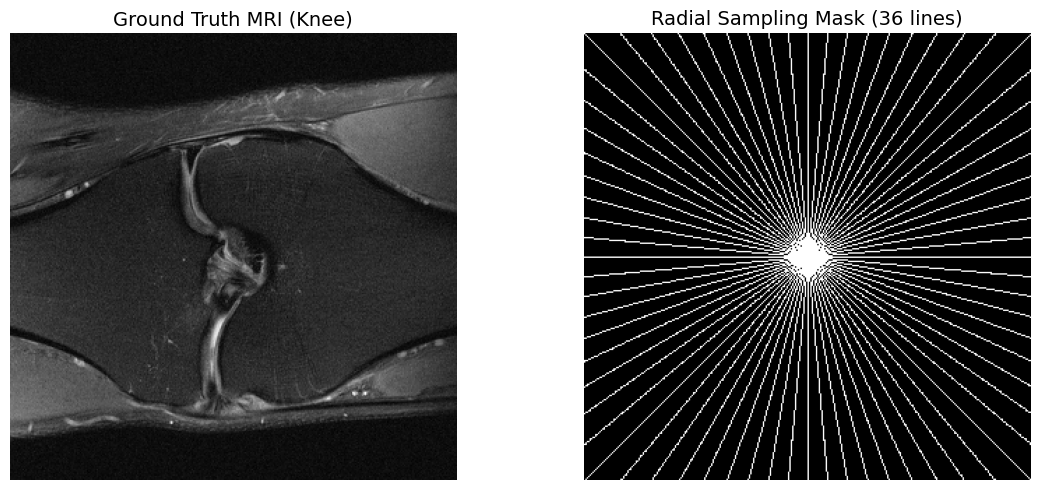

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Ground Truth MRI (Knee)', fontsize=14)
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title(f'Radial Sampling Mask ({metadata["num_lines"]} lines)', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 2. IFFT Baseline

The simplest reconstruction is to zero-fill the missing k-space and apply inverse FFT. This produces severe **streaking artifacts** from radial undersampling.

IFFT SNR: 13.50 dB


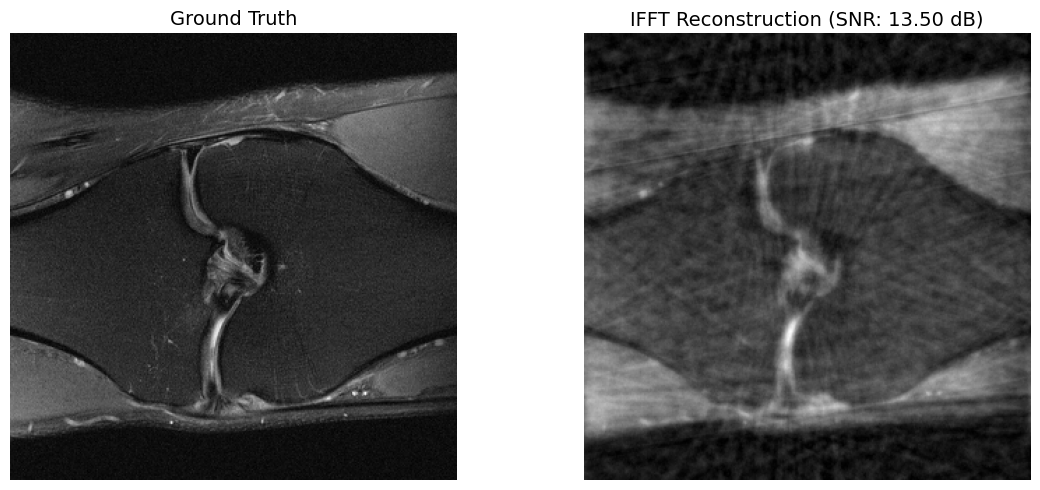

In [4]:
# Load precomputed results
ref_dir = 'evaluation/reference_outputs'
ifft_recon = np.load(os.path.join(ref_dir, 'ifft_recon.npy'))

ifft_snr = compute_snr(img, ifft_recon)
print(f'IFFT SNR: {ifft_snr:.2f} dB')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Ground Truth', fontsize=14)
axes[0].axis('off')

axes[1].imshow(ifft_recon, cmap='gray')
axes[1].set_title(f'IFFT Reconstruction (SNR: {ifft_snr:.2f} dB)', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 3. PnP-MSSN Reconstruction

The Plug-and-Play framework replaces the proximal operator of a regularizer with a learned denoiser. At each iteration:

1. **Gradient step:** $s = x^{(k)} - \gamma \nabla f(x^{(k)})$ where $f(x) = \frac{1}{2}\|Ax - y\|^2$
2. **Denoising step:** $x^{(k+1)} = D_\sigma(\text{clip}(s, 0, \infty))$

The MSSN denoiser uses multi-head attention with recurrent states to exploit non-local self-similarity.

In [5]:
# Load precomputed PnP-MSSN reconstruction
pnp_recon = np.load(os.path.join(ref_dir, 'pnp_mssn_recon.npy'))
snr_history = np.load(os.path.join(ref_dir, 'snr_history.npy'))

pnp_snr = compute_snr(img, pnp_recon)
print(f'PnP-MSSN SNR: {pnp_snr:.2f} dB')
print(f'Improvement over IFFT: {pnp_snr - ifft_snr:.2f} dB')

PnP-MSSN SNR: 17.10 dB
Improvement over IFFT: 3.60 dB


In [ ]:
# To run the full pipeline from scratch (requires GPU + TF):
# os.environ['TF_USE_LEGACY_KERAS'] = '1'
# from src.solvers import MSSNDenoiser, pnp_pgm
# denoiser = MSSNDenoiser(
#     image_shape=img.shape, sigma=metadata['sigma'],
#     model_checkpoints=metadata['model_checkpoints'],
#     patch_size=metadata['patch_size'], stride=metadata['stride'],
#     state_num=metadata['state_num'],
# )
# model = MRIForwardModel(mask)
# recon, history = pnp_pgm(model, denoiser, y, num_iter=200, step=1.0, xtrue=img)

## 4. Reconstruction Progression

The PnP algorithm progressively removes undersampling artifacts over 200 iterations.

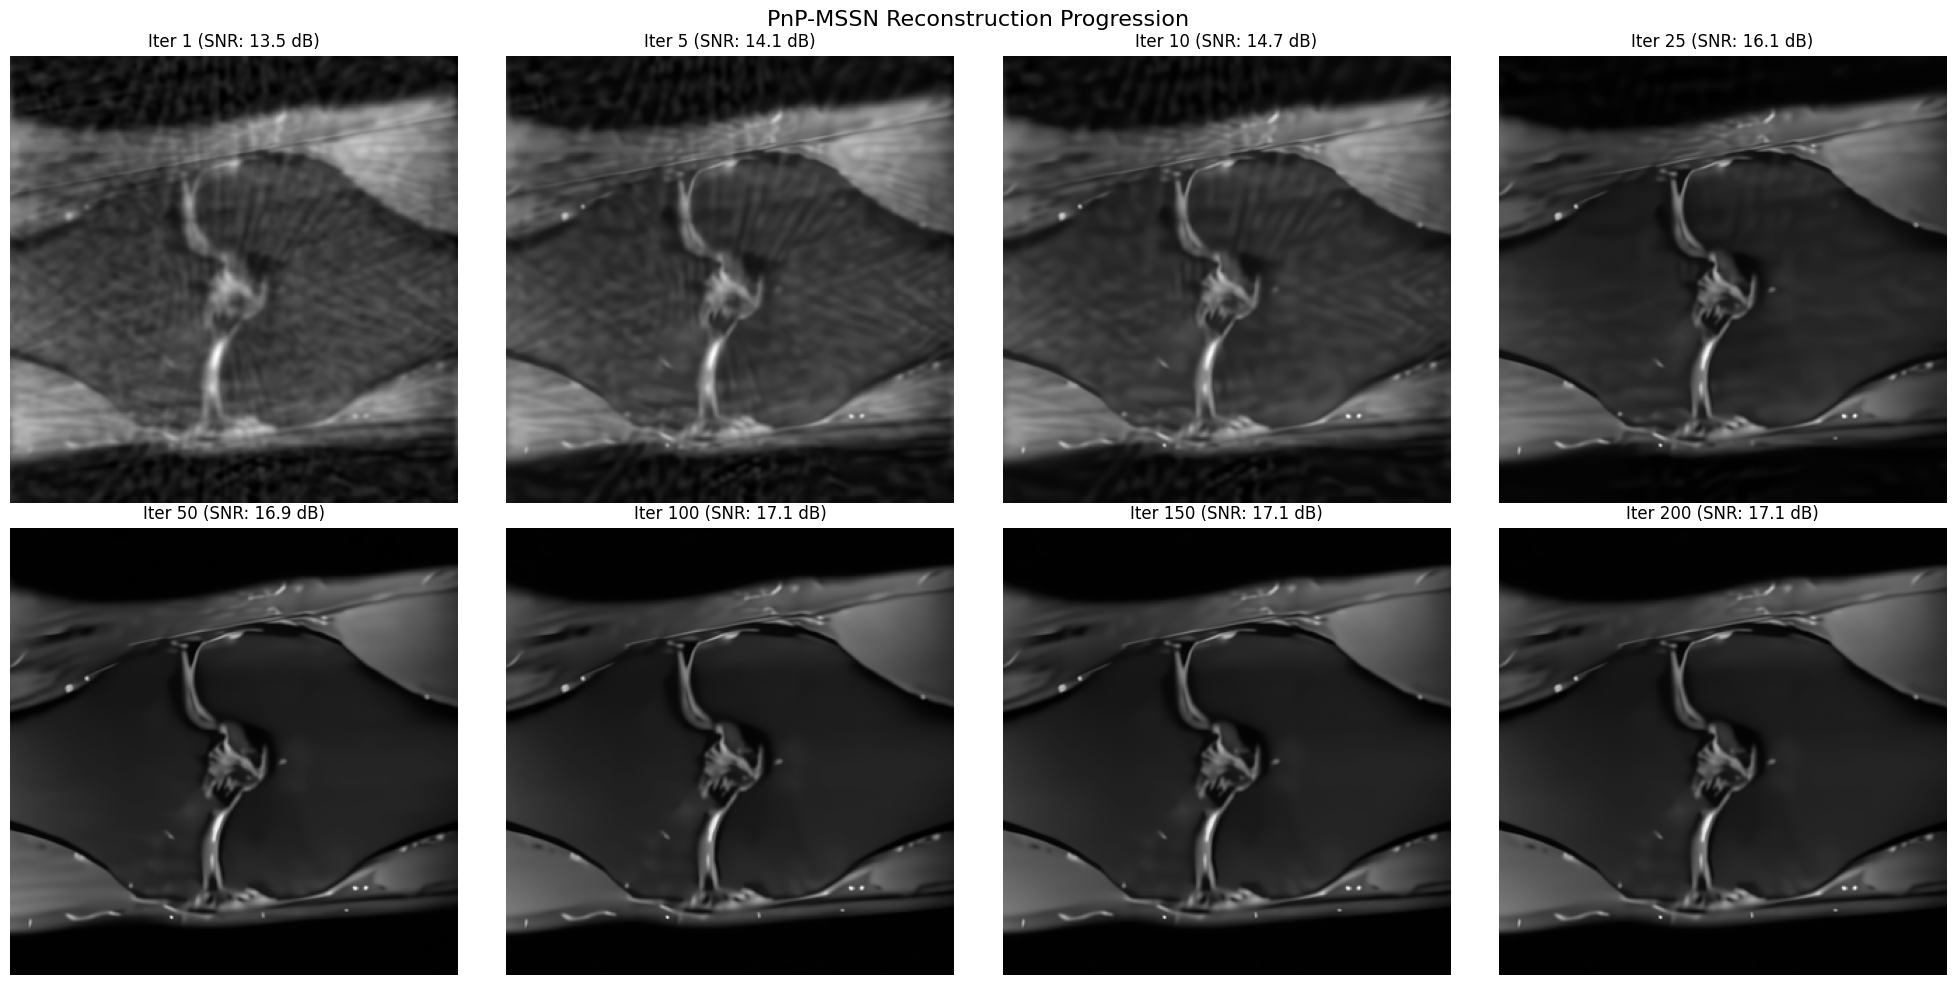

In [6]:
# Load selected iteration reconstructions
selected = np.load(os.path.join(ref_dir, 'selected_iterations.npz'))
iters_to_show = [1, 5, 10, 25, 50, 100, 150, 200]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for idx, it in enumerate(iters_to_show):
    r, c = idx // 4, idx % 4
    recon_it = selected[str(it)]
    snr_it = compute_snr(img, recon_it)
    axes[r, c].imshow(recon_it, cmap='gray')
    axes[r, c].set_title(f'Iter {it} (SNR: {snr_it:.1f} dB)', fontsize=12)
    axes[r, c].axis('off')

plt.suptitle('PnP-MSSN Reconstruction Progression', fontsize=16)
plt.tight_layout()
plt.show()

## 5. Convergence Analysis

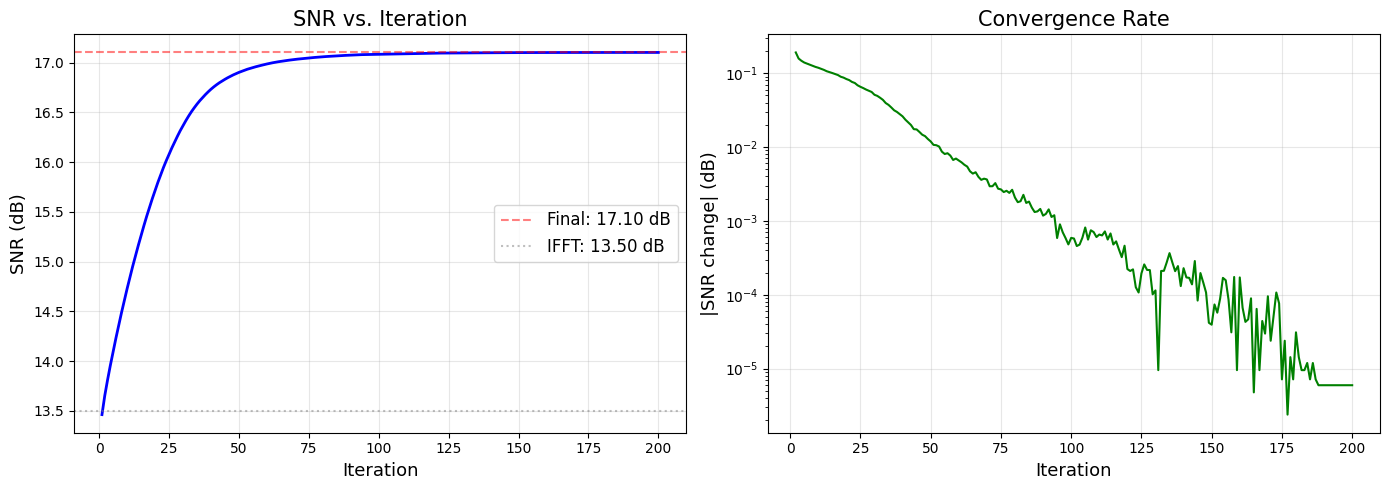

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SNR vs iteration
iters = np.arange(1, len(snr_history) + 1)
axes[0].plot(iters, snr_history, 'b-', linewidth=2)
axes[0].axhline(y=snr_history[-1], color='r', linestyle='--', alpha=0.5,
                label=f'Final: {snr_history[-1]:.2f} dB')
axes[0].axhline(y=ifft_snr, color='gray', linestyle=':', alpha=0.5,
                label=f'IFFT: {ifft_snr:.2f} dB')
axes[0].set_xlabel('Iteration', fontsize=13)
axes[0].set_ylabel('SNR (dB)', fontsize=13)
axes[0].set_title('SNR vs. Iteration', fontsize=15)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# SNR change per iteration
snr_diff = np.abs(np.diff(snr_history))
axes[1].semilogy(iters[1:], snr_diff, 'g-', linewidth=1.5)
axes[1].set_xlabel('Iteration', fontsize=13)
axes[1].set_ylabel('|SNR change| (dB)', fontsize=13)
axes[1].set_title('Convergence Rate', fontsize=15)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Error Maps

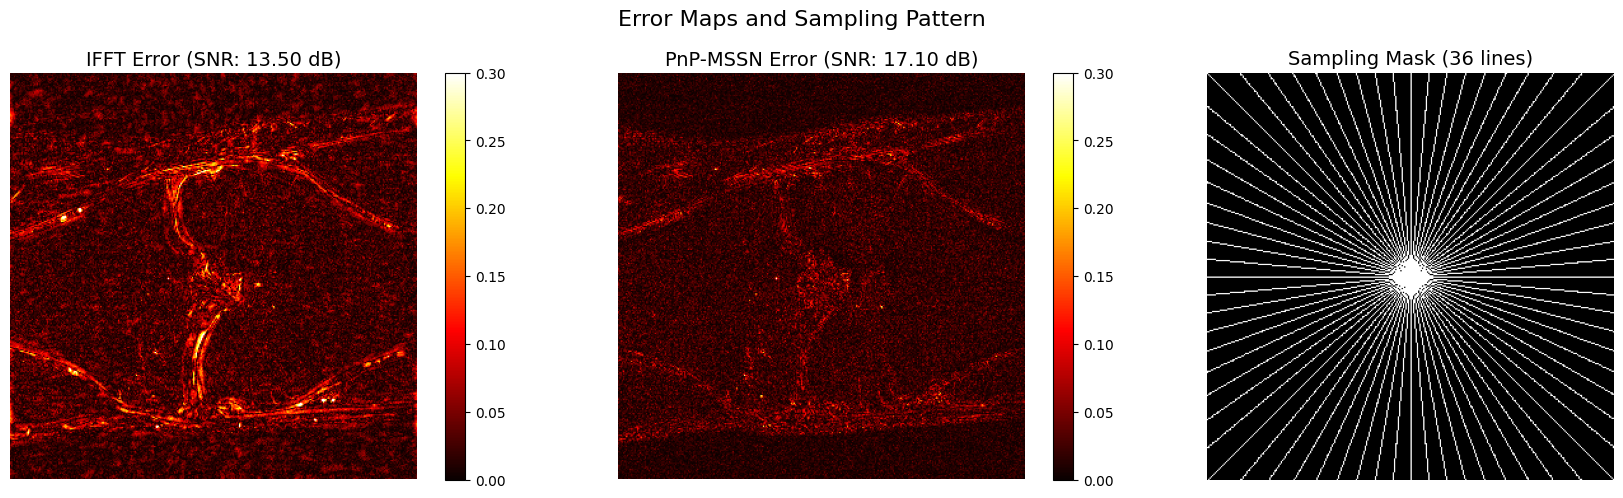

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# IFFT error
ifft_error = np.abs(img - ifft_recon)
im0 = axes[0].imshow(ifft_error, cmap='hot', vmin=0, vmax=0.3)
axes[0].set_title(f'IFFT Error (SNR: {ifft_snr:.2f} dB)', fontsize=14)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# PnP-MSSN error
pnp_error = np.abs(img - pnp_recon)
im1 = axes[1].imshow(pnp_error, cmap='hot', vmin=0, vmax=0.3)
axes[1].set_title(f'PnP-MSSN Error (SNR: {pnp_snr:.2f} dB)', fontsize=14)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Sampling mask
axes[2].imshow(mask, cmap='gray')
axes[2].set_title(f'Sampling Mask ({metadata["num_lines"]} lines)', fontsize=14)
axes[2].axis('off')

plt.suptitle('Error Maps and Sampling Pattern', fontsize=16)
plt.tight_layout()
plt.show()

## 7. Results Comparison

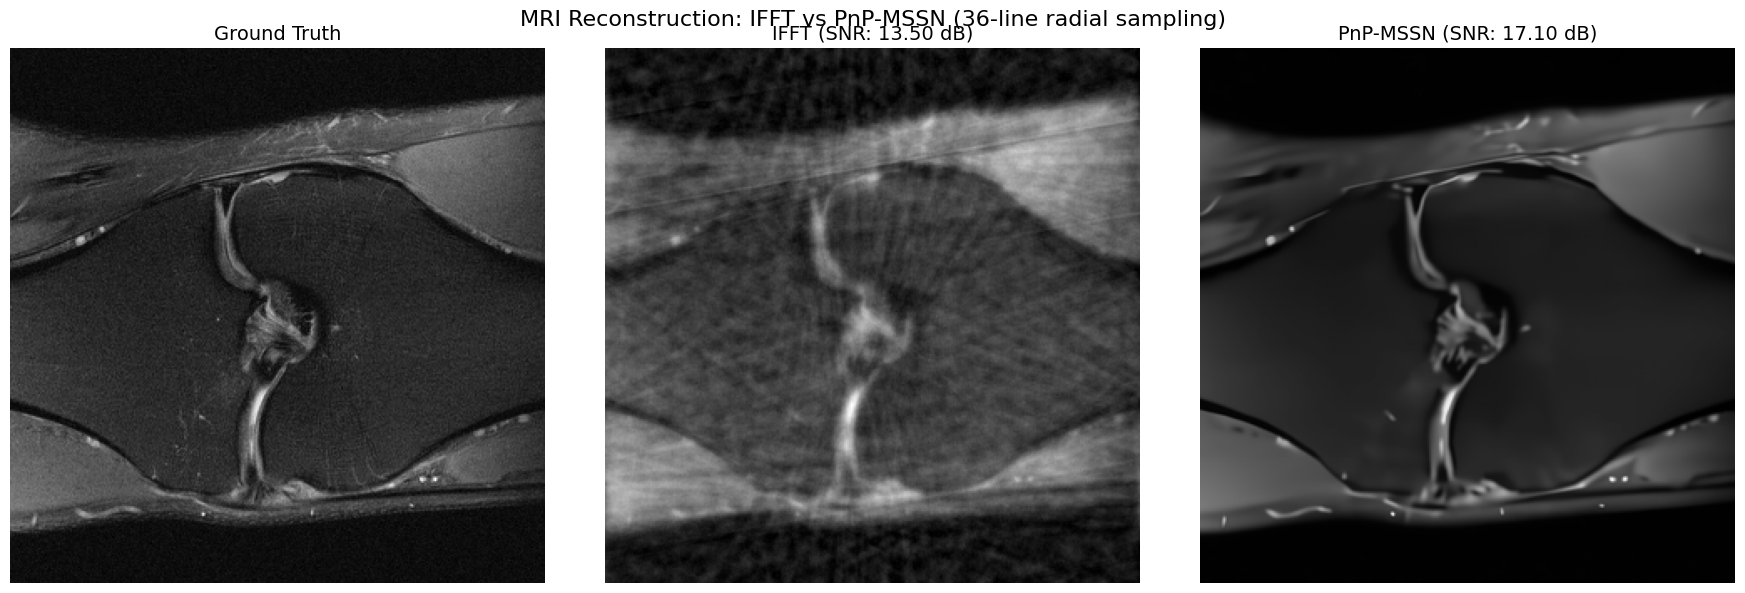

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Ground Truth', fontsize=14)
axes[0].axis('off')

axes[1].imshow(ifft_recon, cmap='gray')
axes[1].set_title(f'IFFT (SNR: {ifft_snr:.2f} dB)', fontsize=14)
axes[1].axis('off')

axes[2].imshow(pnp_recon, cmap='gray')
axes[2].set_title(f'PnP-MSSN (SNR: {pnp_snr:.2f} dB)', fontsize=14)
axes[2].axis('off')

plt.suptitle('MRI Reconstruction: IFFT vs PnP-MSSN (36-line radial sampling)', fontsize=16)
plt.tight_layout()
plt.show()

## 8. Metrics Summary

In [10]:
ifft_m = compute_metrics(img, ifft_recon)
pnp_m = compute_metrics(img, pnp_recon)

print(f"{'Method':<20} {'SNR (dB)':>10} {'NRMSE':>10} {'NCC':>10}")
print('-' * 52)
print(f"{'IFFT':<20} {ifft_m['snr_db']:>10.2f} {ifft_m['nrmse']:>10.4f} {ifft_m['ncc']:>10.4f}")
print(f"{'PnP-MSSN':<20} {pnp_m['snr_db']:>10.2f} {pnp_m['nrmse']:>10.4f} {pnp_m['ncc']:>10.4f}")
print()
print(f"PnP-MSSN achieves {pnp_m['snr_db'] - ifft_m['snr_db']:.1f} dB improvement over IFFT baseline.")

Method                 SNR (dB)      NRMSE        NCC
----------------------------------------------------
IFFT                      13.50     0.2113     0.9774
PnP-MSSN                  17.10     0.1396     0.9902

PnP-MSSN achieves 3.6 dB improvement over IFFT baseline.


## Summary

| Method | SNR (dB) | NRMSE | NCC |
|--------|----------|-------|-----|
| IFFT (zero-filled) | ~13.5 | ~0.21 | ~0.98 |
| PnP-MSSN (200 iter) | ~17.1 | ~0.14 | ~0.99 |

**Key observations:**
- PnP-MSSN achieves ~3.6 dB SNR improvement over naive IFFT reconstruction
- Convergence is stable, with SNR plateauing around iteration 100
- The MSSN denoiser effectively removes streaking artifacts from radial undersampling
- Error maps show that PnP-MSSN significantly reduces errors across the entire image